# Member 2 — EDA and Preprocessing Notebook
## CCS3356 Natural Language Processing | Fake News Detection
### Student ID: CIT-24-01-0486
### Models: Naïve Bayes (ML) + LSTM (DL)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("All imports done!")

All imports done!


[nltk_data] Downloading package stopwords to C:\Users\LENOVO
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LENOVO
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LENOVO
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\LENOVO
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
df = pd.read_csv('../data/merged.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


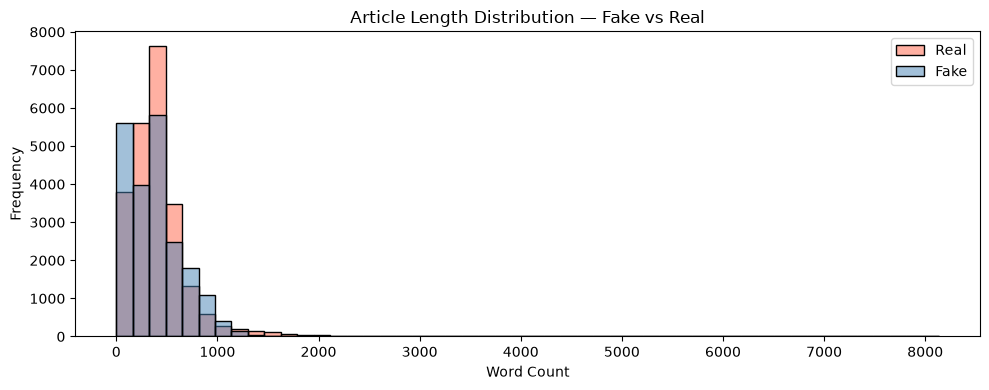

Average fake article length: 423 words
Average real article length: 386 words


In [3]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='text_length', hue='label', bins=50, palette=['steelblue', 'tomato'])
plt.title('Article Length Distribution — Fake vs Real')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend(labels=['Real', 'Fake'])
plt.tight_layout()
plt.savefig('../screenshots/article_length_distribution.png')
plt.show()

print(f"Average fake article length: {df[df['label']==1]['text_length'].mean():.0f} words")
print(f"Average real article length: {df[df['label']==0]['text_length'].mean():.0f} words")

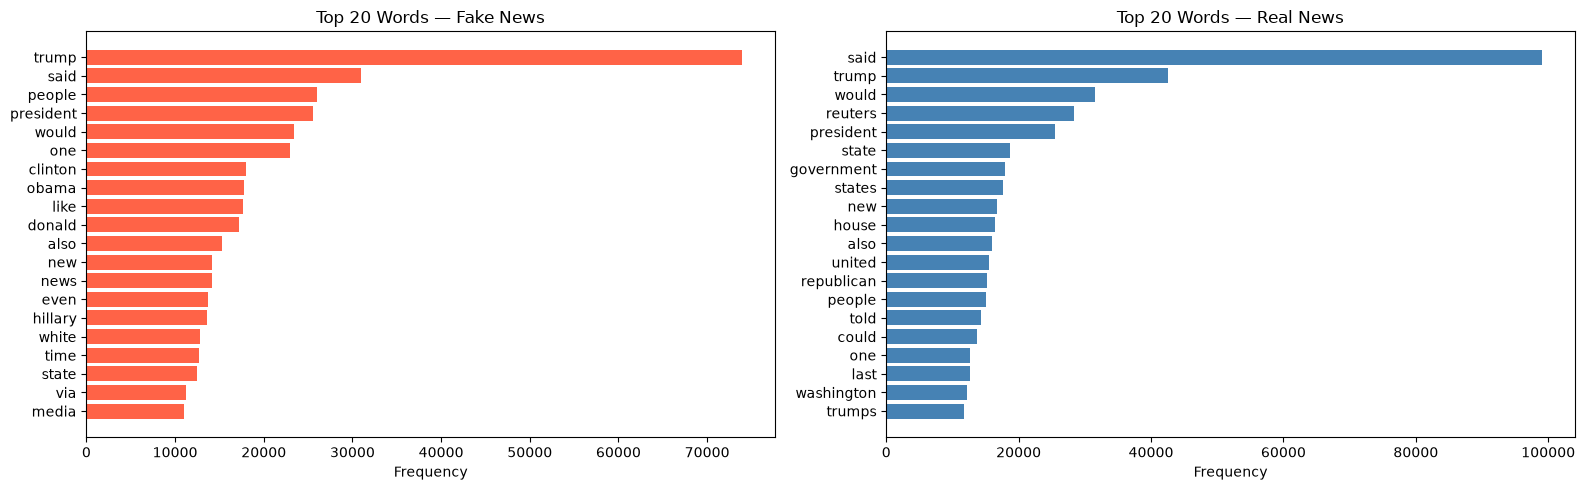

In [4]:
from collections import Counter

stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        for word in str(text).lower().split():
            word = re.sub(r'[^a-z]', '', word)
            if word and word not in stop_words and len(word) > 2:
                words.append(word)
    return Counter(words).most_common(n)

fake_words = get_top_words(df[df['label']==1]['text'])
real_words = get_top_words(df[df['label']==0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fake
axes[0].barh([w[0] for w in fake_words[::-1]], [w[1] for w in fake_words[::-1]], color='tomato')
axes[0].set_title('Top 20 Words — Fake News')
axes[0].set_xlabel('Frequency')

# Real
axes[1].barh([w[0] for w in real_words[::-1]], [w[1] for w in real_words[::-1]], color='steelblue')
axes[1].set_title('Top 20 Words — Real News')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../screenshots/top_words.png')
plt.show()

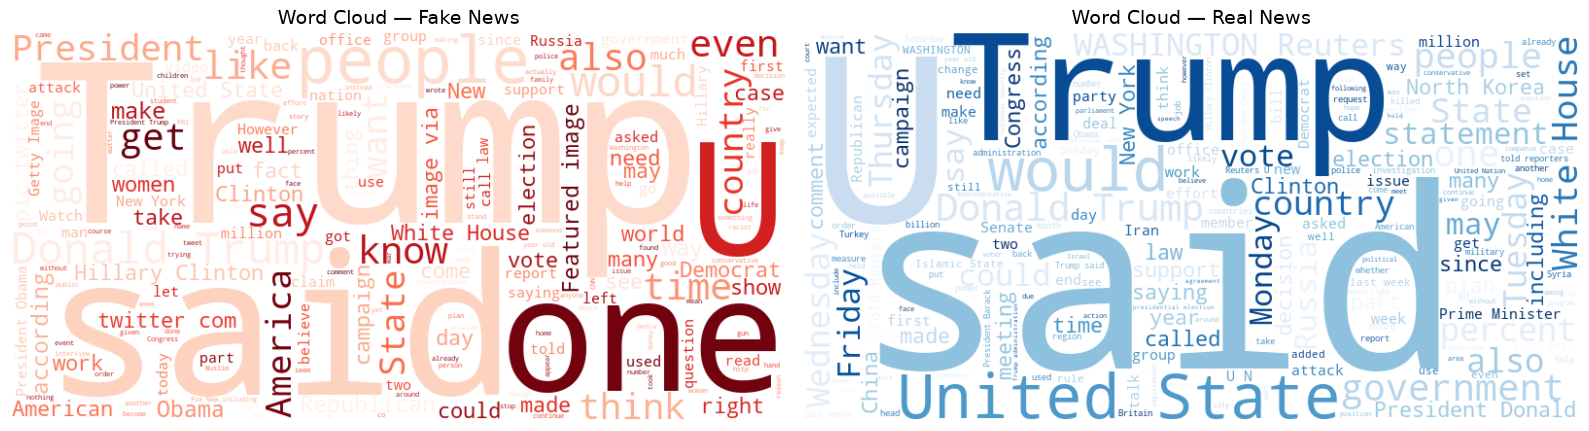

In [5]:
fake_text = ' '.join(df[df['label']==1]['text'].astype(str))
real_text = ' '.join(df[df['label']==0]['text'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_fake = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds', stopwords=stop_words).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Word Cloud — Fake News', fontsize=14)
axes[0].axis('off')

wc_real = WordCloud(width=800, height=400, background_color='white',
                    colormap='Blues', stopwords=stop_words).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Word Cloud — Real News', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../screenshots/wordclouds.png')
plt.show()

<Figure size 1200x500 with 0 Axes>

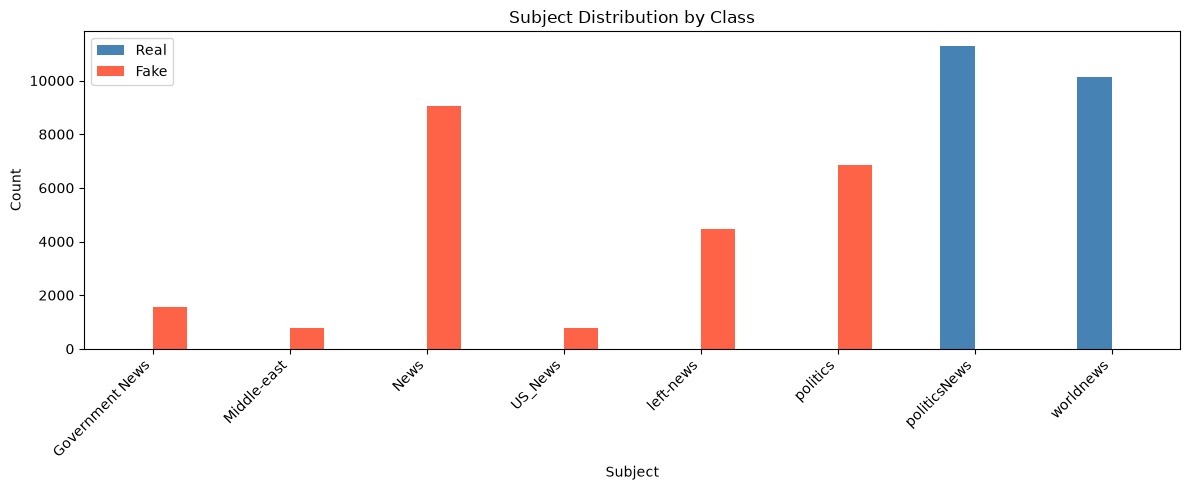

In [6]:
plt.figure(figsize=(12, 5))
subject_counts = df.groupby(['subject', 'label']).size().unstack()
subject_counts.plot(kind='bar', color=['steelblue', 'tomato'], figsize=(12, 5))
plt.title('Subject Distribution by Class')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.legend(['Real', 'Fake'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../screenshots/subject_distribution.png')
plt.show()

## EDA Insights

- Dataset contains **44,898 articles** — 52% fake, 48% real (near-balanced)
- Real articles tend to be **longer** on average than fake articles
- Fake news articles frequently mention political figures and emotionally charged language
- Real articles (Reuters) use more formal, structured language
- Subject categories differ significantly — fake articles cluster around "News" and "politics", real articles around "politicsNews" and "worldnews"
- Word clouds confirm distinct vocabulary patterns between fake and real articles

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

# Test on one example
sample = df['text'].iloc[0]
print("Original text (first 200 chars):")
print(sample[:200])
print("\nPreprocessed text (first 200 chars):")
print(preprocess_text(sample)[:200])

Original text (first 200 chars):
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative s

Preprocessed text (first 200 chars):
century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing 


In [9]:
print("Applying preprocessing — this may take a few minutes...")
df['cleaned_text'] = df['text'].apply(preprocess_text)
print("Done!")
print(f"\nOriginal text sample: {df['text'].iloc[0][:100]}")
print(f"Cleaned text sample:  {df['cleaned_text'].iloc[0][:100]}")

Applying preprocessing — this may take a few minutes...
Done!

Original text sample: 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Holl
Cleaned text sample:  century wire say ben stein reputable professor pepperdine university also hollywood fame appearing s


In [10]:
# Save only the columns we need
df_clean = df[['title', 'text', 'cleaned_text', 'label']].copy()
df_clean.to_csv('../data/preprocessed.csv', index=False)
print(f"Preprocessed dataset saved!")
print(f"Shape: {df_clean.shape}")
df_clean.head()

Preprocessed dataset saved!
Shape: (44898, 4)


,title,text,cleaned_text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",century wire say ben stein reputable professor...,1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,washington reuters president donald trump remo...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,reuters puerto rico governor ricardo rossello ...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrassed country accide...,1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland reuters presidential candidat...,0
